In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import func_notebook as nbk
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

In [3]:
filepaths =[
    '/disk/gfs_atp/hekinc/Master_measurements/2026_07_21_Warm_single_ended/alpine_warm_2.4V_400Hz_single_ended/RAW/DataR_CH0@DT5730S_59483_alpine_warm_2.4V_400Hz_single_ended.CSV',
    '/disk/gfs_atp/hekinc/Master_measurements/2026_07_21_Warm_single_ended/alpine_warm_2.6V_400Hz_single_ended/RAW/DataR_CH0@DT5730S_59483_alpine_warm_2.6V_400Hz_single_ended.CSV',
    '/disk/gfs_atp/hekinc/Master_measurements/2026_07_21_Warm_single_ended/alpine_warm_2.53V_400Hz_single_ended/RAW/DataR_CH0@DT5730S_59483_alpine_warm_2.53V_400Hz_single_ended.CSV',
]

Total events: 120085
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 54677
Rejected by bad window length: 0
Successfully integrated: 65408


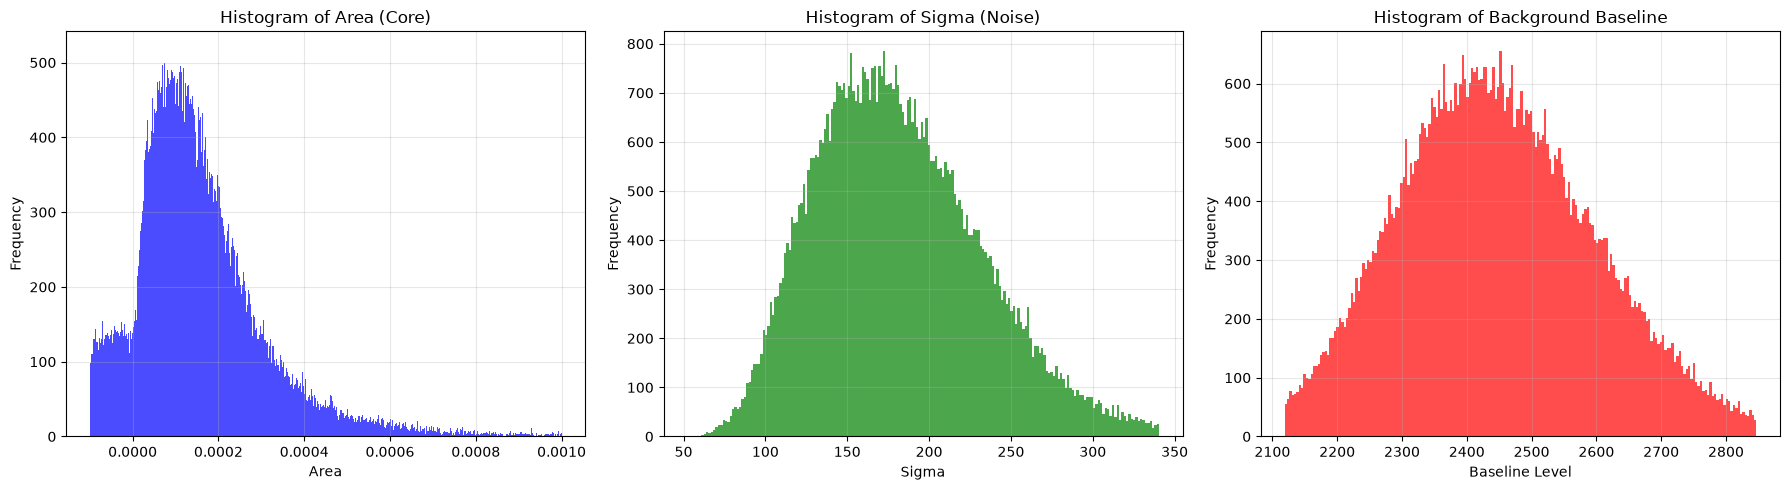

Processing 65408 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 1.062360e-04
Detector Gain:      2.136204e-04
Pedestal Noise (σ_0): 9.510996e-05
1-Photon Noise (σ_1): 1.000000e-12
----------------------------
Peak 0: μ = 1.062360e-04, σ = 9.510996e-05
Peak 1: μ = 3.198565e-04, σ = 9.510996e-05
Peak 2: μ = 5.334769e-04, σ = 9.510996e-05


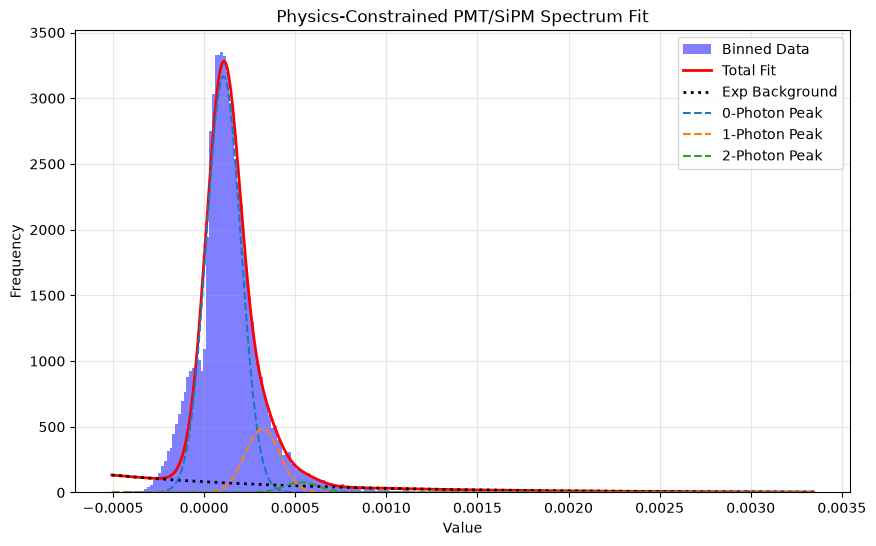

(array([8.21116909e+01, 9.50597375e+02, 1.06236044e-04, 9.51099592e-05,
        2.13620423e-04, 1.00000000e-12, 3.16718219e+03, 4.84596629e+02,
        7.79152318e+01, 1.28067147e-26, 1.59210625e-39, 2.10014994e-34,
        1.07020891e-35, 8.21501427e-37, 7.74336673e-35, 1.37351273e-35,
        9.25424080e-25, 5.37701527e-18]),
 array([[ 8.40535445e+02, -2.07478347e+04, -2.30197397e-05,
         -4.00499806e-05, -2.70338144e-04,  1.04727838e+00,
         -1.13161486e+03, -2.88685193e+02, -7.64322344e+02,
         -8.73529844e+02, -9.07561492e+02, -8.29410882e+02,
         -7.68469974e+02, -6.97589109e+02, -6.24204965e+02,
         -5.68477913e+02, -4.60462313e+02, -5.54809335e+02],
        [-2.07478347e+04,  7.43165470e+05,  4.87932123e-04,
          8.59481798e-04,  5.79951810e-03, -2.06854352e+01,
          2.84592311e+04,  1.30382068e+04,  2.45939723e+04,
          2.80072869e+04,  2.89299751e+04,  2.70401284e+04,
          2.52768594e+04,  2.31698244e+04,  2.08753420e+04,
         

In [7]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[0], 250000000)
nbk.plotter(array_area, array_sigma, array_bkg)
nbk.analyze_and_fit_physics(array_area, bins=250)

Total events: 120058
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 80559
Rejected by bad window length: 0
Successfully integrated: 39499


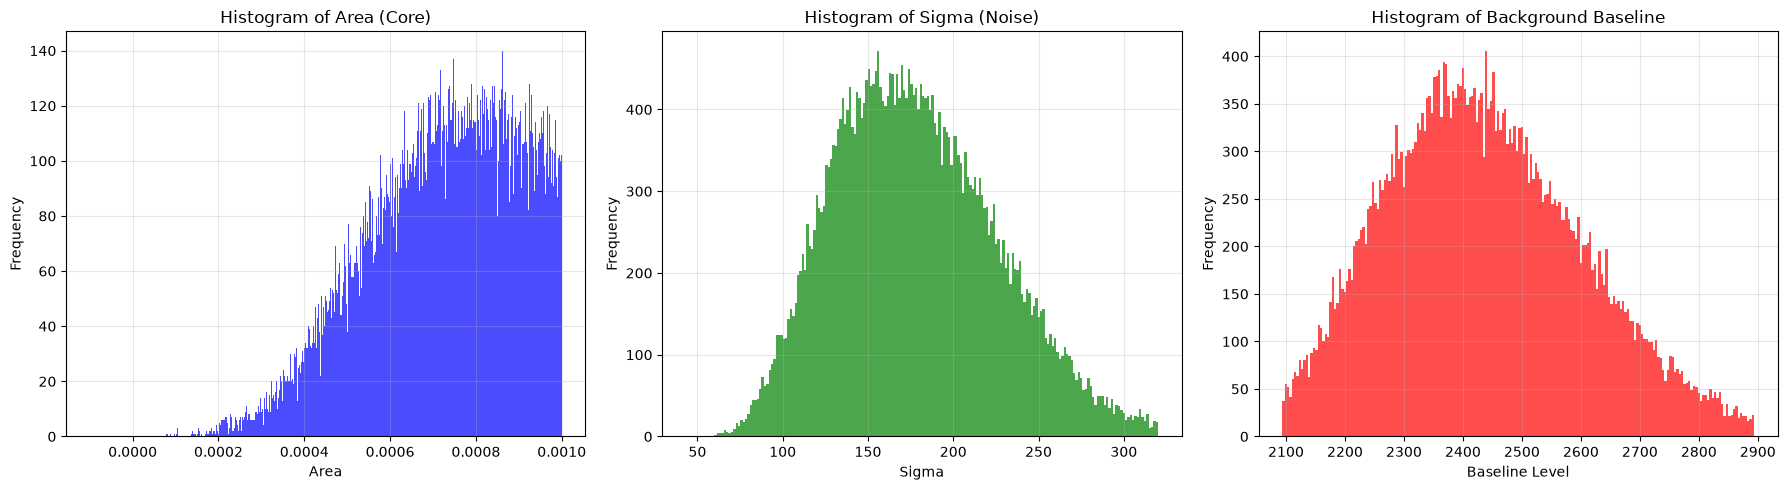

Processing 39499 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 8.150106e-04
Detector Gain:      2.952538e-04
Pedestal Noise (σ_0): 2.384020e-05
1-Photon Noise (σ_1): 7.934127e-06
----------------------------
Peak 0: μ = 8.150106e-04, σ = 2.384020e-05
Peak 1: μ = 1.110264e-03, σ = 2.512580e-05
Peak 2: μ = 1.405518e-03, σ = 2.634874e-05
Peak 3: μ = 1.700772e-03, σ = 2.751738e-05
Peak 4: μ = 1.996026e-03, σ = 2.863838e-05
Peak 5: μ = 2.291280e-03, σ = 2.971712e-05


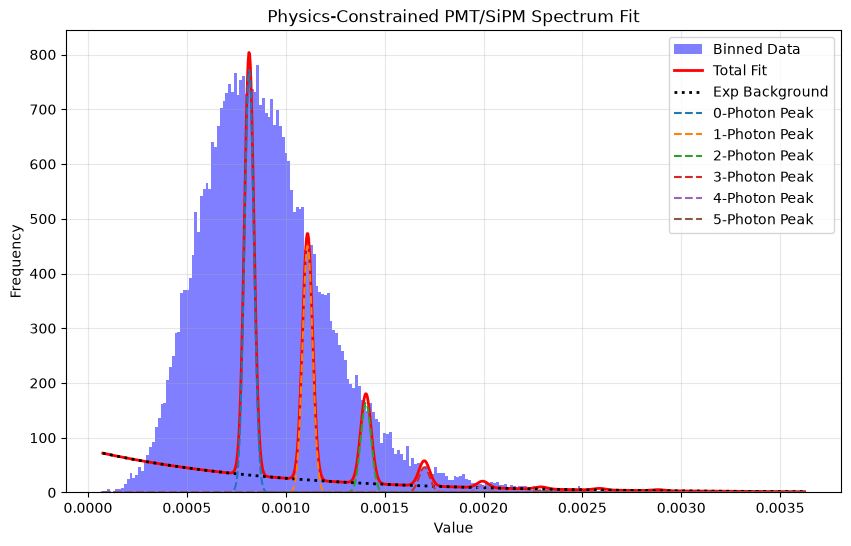

(array([7.80000051e+01, 1.09997874e+03, 8.15010623e-04, 2.38402040e-05,
        2.95253843e-04, 7.93412691e-06, 7.73000000e+02, 4.51000000e+02,
        1.64000000e+02, 4.60000000e+01, 1.20000000e+01, 4.00000000e+00,
        3.00000000e+00, 2.00000000e+00, 1.00000000e-10, 1.00000000e-10,
        1.00000000e-09, 1.00000000e-09]),
 array([[ 5.80693667e+03,  9.44841086e+04,  6.13101561e-06,
         -4.48935243e-06, -6.96062026e-07,  3.05606661e-04,
          1.85267661e+02,  1.60298056e+02,  8.10033983e+02,
          1.24668058e+03,  1.33077396e+03,  1.23286384e+03,
          1.06671815e+03,  9.00088342e+02,  7.56050257e+02,
          6.13941312e+02,  2.67686967e+06,  0.00000000e+00],
        [ 9.44841086e+04,  2.73343085e+06,  1.13706909e-04,
          1.10547896e-03, -7.51183496e-05,  1.18045219e-02,
          2.77711937e+04,  1.63823585e+04,  3.65620990e+04,
          4.90459133e+04,  4.91715700e+04,  4.36999097e+04,
          3.66361480e+04,  3.02170900e+04,  2.50307021e+04,
         

In [8]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[1], 250000000)
nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, bins=250)

Total events: 120058
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 77078
Rejected by bad window length: 0
Successfully integrated: 42980


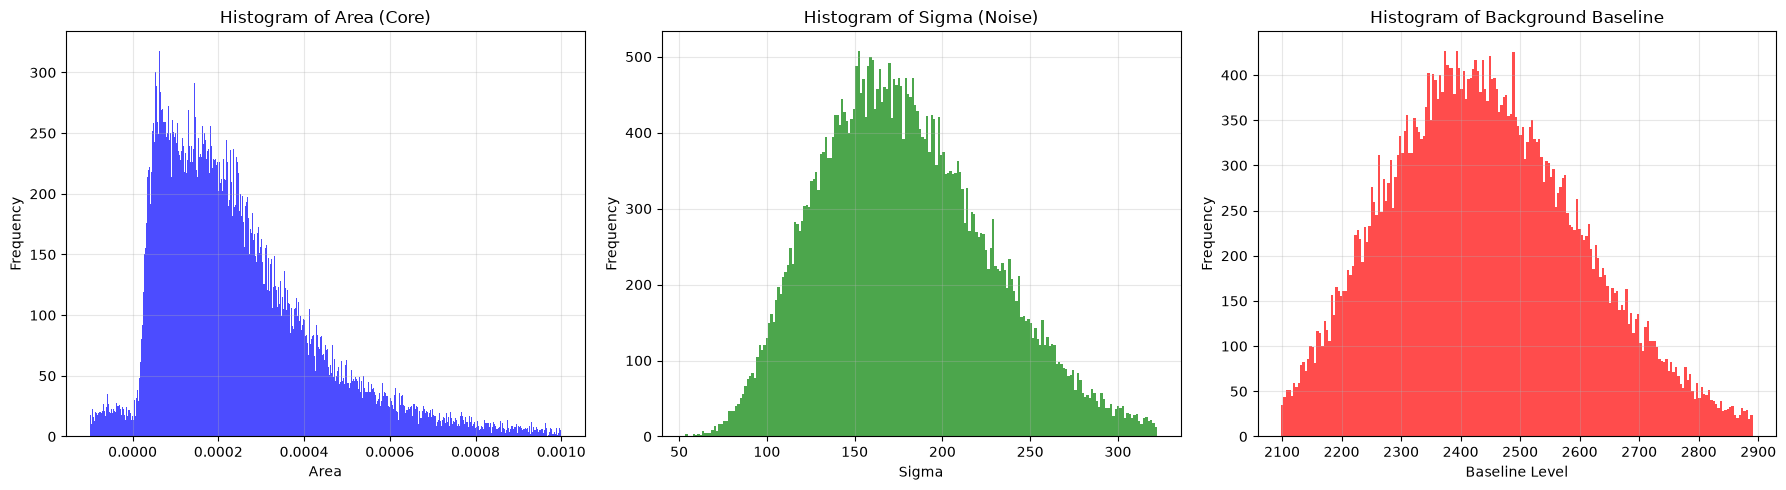

In [6]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[2], 250000000)
nbk.plotter(array_area, array_sigma, array_bkg)